# Reacher env

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt

class ReacherRewardWrapper(gym.Wrapper):
    def __init__(self, env, control_cost_weight=1.0):
        super().__init__(env)
        self.control_cost_weight = control_cost_weight

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        reward_dist = info['reward_dist']
        reward_ctrl = info['reward_ctrl']
        new_reward = reward_dist + self.control_cost_weight * reward_ctrl
        return obs, new_reward, terminated, truncated, info

CONTROL_WEIGHTS_TO_TRAIN = [1, 2, 3, 4, 5]

TOTAL_TIMESTEPS = 3000000  

print(f"--- Starting automated training for {len(CONTROL_WEIGHTS_TO_TRAIN)} models ---")

for weight in CONTROL_WEIGHTS_TO_TRAIN:
    print("\n" + "="*50)
    print(f"STARTING TRAINING FOR: control_cost_weight = {weight}")
    print("="*50)

    model_filename = f"ppo_reacher_weight_{weight}"
    env_filename = f"vec_normalize_reacher_weight_{weight}.pkl"

    def make_reacher_env():
        env = gym.make("Reacher-v4")
        env = ReacherRewardWrapper(env, control_cost_weight=weight)
        return env

    train_env = DummyVecEnv([make_reacher_env])
    train_env = VecNormalize(train_env, norm_obs=True, norm_reward=False, clip_obs=10.)

    model = PPO("MlpPolicy", train_env, verbose=1, device="cpu")
    model.learn(total_timesteps=TOTAL_TIMESTEPS)

    model.save(model_filename)
    train_env.save(env_filename)
    train_env.close()

    print(f"\n--- COMPLETED training for weight = {weight} ---")
    print(f"Model saved to: {model_filename}.zip")
    print(f"Env stats saved to: {env_filename}")

print("\n" + "="*50)
print("All training runs are complete.")
print("="*50)

--- Starting automated training for 6 models ---

STARTING TRAINING FOR: control_cost_weight = 0
Using cpu device


/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


-----------------------------
| time/              |      |
|    fps             | 2294 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1687         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0052609285 |
|    clip_fraction        | 0.0429       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.85        |
|    explained_variance   | 0.102        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.46         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00549     |
|    std                  | 1.01         |
|    value_loss           | 2.57         |
----------------

/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


-----------------------------
| time/              |      |
|    fps             | 2369 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1751        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008486593 |
|    clip_fraction        | 0.0715      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_variance   | -0.0151     |
|    learning_rate        | 0.0003      |
|    loss                 | 56.8        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0124     |
|    std                  | 0.988       |
|    value_loss           | 182         |
----------------------------------

--- Loading all policies ---
Loading model for weight: 1
Loading model for weight: 2
Loading model for weight: 3
Loading model for weight: 4
Loading model for weight: 5

--- Running comparison for 1000 steps ---
Driver policy is the one trained with weight = 1
--- Plotting action distributions ---


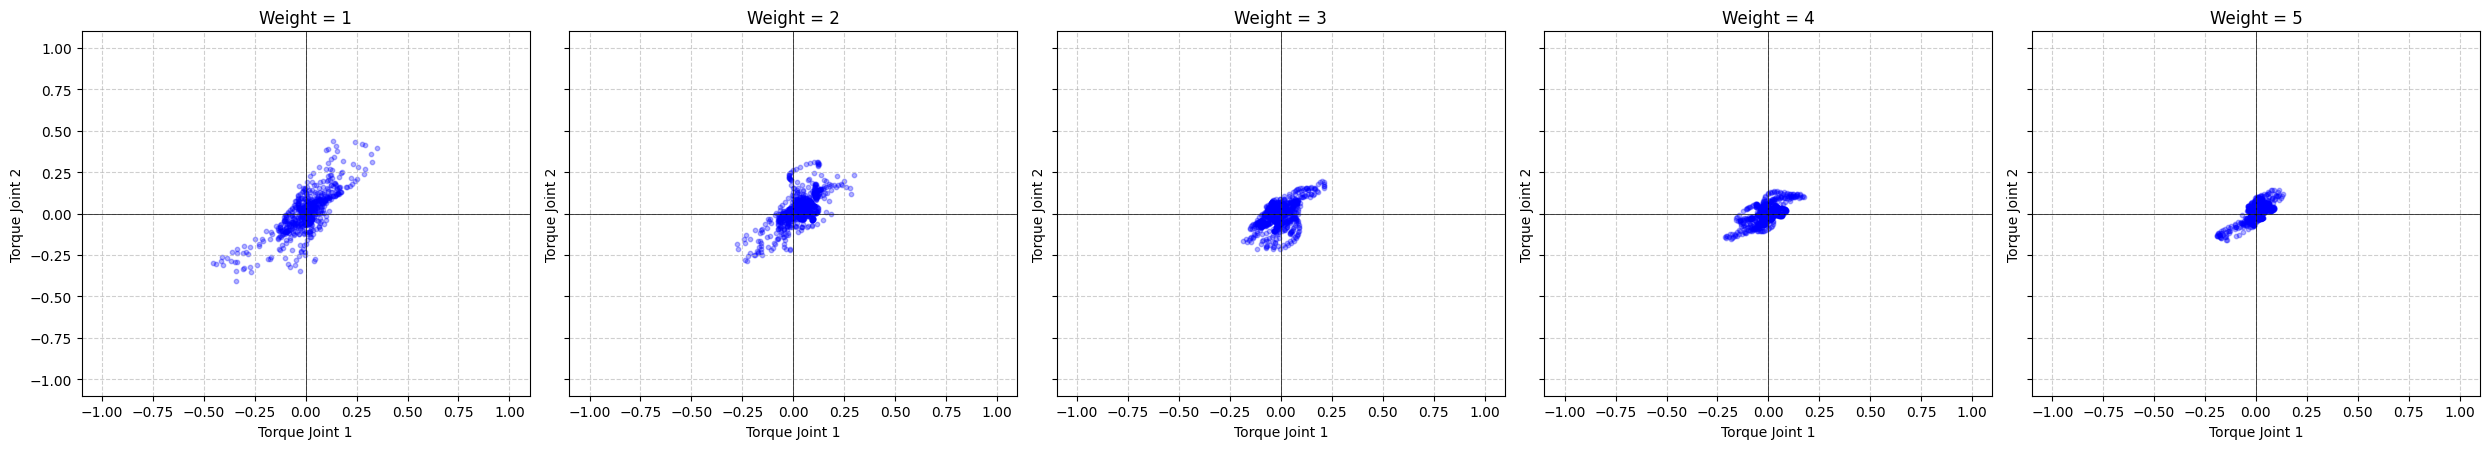

In [ ]:
POLICY_CONFIG = {
    1: "ppo_reacher_weight_1",
    2: "ppo_reacher_weight_2",
    3: "ppo_reacher_weight_3",
    4: "ppo_reacher_weight_4",
    5: "ppo_reacher_weight_5",
}
DRIVER_WEIGHT = 1
DRIVER_MODEL_FILE = POLICY_CONFIG[DRIVER_WEIGHT]
DRIVER_ENV_FILE = f"vec_normalize_reacher_weight_{DRIVER_WEIGHT}.pkl"
NUM_COMPARISON_STEPS = 1000

print("--- Loading all policies ---")
loaded_policies = {}
for weight, filename in POLICY_CONFIG.items():
    print(f"Loading model for weight: {weight}")
    loaded_policies[weight] = PPO.load(filename, device="cpu")

def make_reacher_env():
    env = gym.make("Reacher-v4")
    env = ReacherRewardWrapper(env, control_cost_weight=DRIVER_WEIGHT)
    return env

eval_env = VecNormalize.load(DRIVER_ENV_FILE, DummyVecEnv([make_reacher_env]))
eval_env.training = False

print(f"\n--- Running comparison for {NUM_COMPARISON_STEPS} steps ---")
print(f"Driver policy is the one trained with weight = {DRIVER_WEIGHT}")
actions_log = {weight: [] for weight in POLICY_CONFIG.keys()}
obs_log = []

obs = eval_env.reset()
for _ in range(NUM_COMPARISON_STEPS):
    obs_log.append(obs.flatten())
    for weight, policy in loaded_policies.items():
        action, _ = policy.predict(obs, deterministic=True)
        actions_log[weight].append(action.flatten())

    driver_action, _ = loaded_policies[DRIVER_WEIGHT].predict(obs, deterministic=True)
    obs, _, _, _ = eval_env.step(driver_action)

eval_env.close()

for weight in actions_log:
    actions_log[weight] = np.array(actions_log[weight])

obs_log = np.array(obs_log)

print("--- Plotting action distributions ---")
num_policies = len(POLICY_CONFIG)
fig, axes = plt.subplots(1, num_policies, figsize=(num_policies * 5, 5), sharex=True, sharey=True)
plot_color = 'blue'

for ax, weight in zip(axes, sorted(POLICY_CONFIG.keys())):
    actions = actions_log[weight]
    
    ax.scatter(actions[:, 0], actions[:, 1], alpha=0.3, s=10, c=plot_color)
    
    ax.set_title(f'Weight = {weight}')
    ax.set_xlabel('Torque Joint 1')
    ax.set_ylabel('Torque Joint 2')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
# for each weight in action log, concat the observations to the actions
for weight in actions_log:
    actions_log[weight] = np.concatenate((actions_log[weight], obs_log), axis=1)

In [ ]:
import torch
torch.save(torch.tensor(actions_log[1]), "reacher_data_1.pt")
torch.save(torch.tensor(actions_log[2]), "reacher_data_2.pt")
torch.save(torch.tensor(actions_log[3]), "reacher_data_3.pt")
torch.save(torch.tensor(actions_log[4]), "reacher_data_4.pt")
torch.save(torch.tensor(actions_log[5]), "reacher_data_5.pt")
